# 1. Basic Information

Estratégias de Processamento de Dados em Larga Escala

Grupo 2: 
- Bernardo Henriques nº52365
- Guilherme Cardoso nº51631
- Dinis Amado nº51556

### Declaração de Integridade

Eu, Bernardo Henriques, Guilherme Cardoso e Dinis Amado, estudantes com os números de inscrição 52365, 51631 e 51556 (respetivamente) de/o 1º Ciclo em Inteligência Artificial e Ciência de Dados da Universidade da Beira Interior, declaro ter desenvolvido o presente trabalho e elaborado o presente texto em total consonância com o Código de Integridade da Universidade da Beira Interior. Mais concretamente afirmo não ter incorrido em qualquer das variedades de Fraude Académica, e que aqui declaro conhecer, que em particular atendi à exigida referenciação de frases, extratos, imagens e outras formas de trabalho intelectual, e assumindo assim na íntegra as responsabilidades da autoria.

Universidade da Beria Interior

19/05/2026

### Declaração do uso de IA Generativa

De acordo com as diretrizes do projeto, declaramos o uso das seguintes ferramentas de Inteligência Artificial Generativa na preparação deste trabalho:

* **Ferramentas e serviços usados:** Google Gemini e Claude.
* **Contribuições das ferramentas:** O modelo de IA Generativa Gemini foi utilizado como assistente de desenvolvimento ao longo do projeto. A sua ajuda focou-se na estruturação do ciclo de processamento por blocos (*chunking*) para leitura do dataset completo e na otimização estética das visualizações finais. Adicionalmente, auxiliou na resolução de conflitos de versões e configuração do repositório Git/GitHub que por sua vez simplificou o trabalho do grupo todo. Todo o código final, decisões técnicas e a redação das análises críticas foram inteiramente revistos, executados e validados pelos membros do grupo.

# 2. Contribution

| Aluno | Horas de trabalho | Contributos Detalhados |
| :--- | :--- | :--- |
| Bernardo Henriques | 7h | Resolução das alíneas 1 a 4 do exercício 2 |
| Guilherme Cardoso | 6h | Resolução das alíneas 5 a 8 do exercício 2 |
| Dinis Amado | 7h | Resolução do exercício 1 |

# 3. Background and Motivation

### 3.1 Contextualização
Na era do *Big Data*, as plataformas digitais geram volumes massivos de dados de navegação e transações a cada segundo. Ficheiros de registos (*logs*) que contêm interações de utilizadores (como visualizações de produtos, adições ao carrinho e compras efetuadas) atingem rapidamente dimensões na ordem dos gigabytes (GB). Para os cientistas e analistas de dados, extrair conhecimento útil destes ficheiros em tempo real é um desafio crítico, uma vez que os conjuntos de dados excedem frequentemente a capacidade da memória RAM dos computadores convencionais.

### 3.2 Motivação
Este projeto surge da necessidade premente de aplicar estratégias avançadas de engenharia e processamento de dados em larga escala. A principal motivação é demonstrar que, mesmo com limitações de hardware local, é possível carregar, limpar, otimizar e analisar datasets multimilionários através do uso de técnicas algorítmicas inteligentes e manipulação eficiente de estruturas de dados em Python.

### 3.3 Objetivo
O objetivo principal é analisar de dados em larga escala. Para o fazer, estabeleceram-se como metas intermédias: a implementação de processamento iterativo por blocos (*chunking*), a redução drástica da pegada de memória RAM  de tipos, o tratamento computacional de valores em falta à escala global e a criação de visualizações analíticas de alto impacto sobre o comportamento dos consumidores.

### 3.4 Resultados Obtidos
No exercício 2, através da nossa *pipeline* de processamento iterativo no Pandas, conseguimos contornar as restrições físicas de memória e analisar com sucesso mais de 40 milhões de registos. A estratégia de otimização de tipos (conversão para categorias e redução de precisão numérica) resultou numa poupança real de **68.37%** de memória RAM (reduzindo o peso de uma amostra de 247.56 MB para uns eficientes 78.30 MB). No campo analítico, gerámos com sucesso um mapa de calor de tráfego horário global e identificámos com precisão as marcas líderes de faturação (lideradas de forma isolada pela Apple).

### 3.5 Melhorias Futuras
Para desenvolvimentos futuros, poderiamos migrar este ecossistema local para uma arquitetura de computação distribuída, utilizando ferramentas como Apache Spark ou Dask. Esta transição permitiria realizar agregações ainda mais complexas e aplicar modelos de aprendizagem computacional (*Machine Learning*) para previsão de conversão (*churn* e recomendação) diretamente no fluxo de dados em larga escala.

### 3.6 Dificuldades e Resolução de Problemas
O desenvolvimento do projeto e a gestão do ambiente de trabalho foram executados de forma iterativa, enfrentando desafios técnicos que foram superados através das seguintes abordagens:

**1. Fase de Desenvolvimento e Teste em Amostra (Chunking Inicial):**
Devido à impossibilidade de carregar o ficheiro completo de 5.67 GB de uma só vez, a lógica de otimização de tipos e filtragem de dados foi inicialmente desenhada e validada utilizando uma amostra controlada (o primeiro bloco de 1.000.000 de linhas). Isto permitiu detetar particularidades do Pandas, como a diferença entre a estimativa superficial do método `df.info()` e o consumo real detalhado por `memory_usage(deep=True)`. Adicionalmente, mitigámos problemas visuais em gráficos causados pela retenção de categorias vazias na memória do Pandas, forçando a conversão explícita de eixos para strings.

### Bibliotecas necessárias
```bash
pandas
numpy
matplotlib
seaborn

In [ ]:
pip install pandas numpy matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Exercício 1

Criação do plano estratégico e das variáveis de suporte para que as alineas seguintes consigam ler o ficheiro mais facilmente

In [ ]:
# Colunas value1 a value31
VALUE_COLS = [f'value{i}' for i in range(1, 32)]
USE_COLS   = ['id', 'year', 'month', 'element'] + VALUE_COLS
 
DATA_FILE     = 'data/ghcnd_daily.csv'
STATIONS_FILE = 'data/ghcnd-stations.txt'
CHUNK_SIZE    = 500_000

### 1. Leitura de um chunk e otimização de tipos de dados.

In [ ]:
# Read only the first chunk; -9999 is treated as NaN
reader = pd.read_csv(
    DATA_FILE,
    usecols=USE_COLS,
    na_values=[-9999],
    chunksize=CHUNK_SIZE,
    low_memory=False
)
df = next(reader)
 
print(f"Chunk shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(df.head(3))
 
# Uso de memória antes da otimização:
mem_before = df.memory_usage(deep=True).sum() / 1024**2
print(f"\nMemory before optimisation: {mem_before:.2f} MB")
print(df.dtypes)
 
# Otimização de tipos de dados:
#   id, element  -> category  (strings repetidas — grande economia de memória)
#   year         -> int16     (cabe entre -32768 e 32767)
#   month        -> int8      (1-12)
#   value1..31   -> float32   (precisão suficiente para décimos de grau)
df['id']      = df['id'].astype('category')
df['element'] = df['element'].astype('category')
df['year']    = df['year'].astype('int16')
df['month']   = df['month'].astype('int8')
for col in VALUE_COLS:
    df[col] = df[col].astype('float32')
 
mem_after = df.memory_usage(deep=True).sum() / 1024**2
print(f"\nMemory after optimisation: {mem_after:.2f} MB")
print(f"Reduction: {(1 - mem_after/mem_before)*100:.1f}%")
print(df.dtypes)

Chunk shape: 500,000 rows x 35 columns
            id  year  month element  value1  value2  value3  value4  value5  \
0  ACW00011604  1949      1    TMAX   289.0   289.0   283.0   283.0   289.0   
1  ACW00011604  1949      2    TMAX   267.0   278.0   272.0   267.0   278.0   
2  ACW00011604  1949      3    TMAX   272.0   289.0   278.0   278.0   278.0   

   value6  ...  value22  value23  value24  value25  value26  value27  value28  \
0   289.0  ...    272.0    267.0    267.0    267.0    278.0    272.0    272.0   
1   278.0  ...    272.0    272.0    267.0    267.0    267.0    267.0    272.0   
2   278.0  ...    272.0    278.0    278.0    261.0    261.0    267.0    267.0   

   value29  value30  value31  
0    272.0    272.0    272.0  
1      NaN      NaN      NaN  
2    283.0    278.0    267.0  

[3 rows x 35 columns]

Memory before optimisation: 187.40 MB
id             str
year         int64
month        int64
element        str
value1     float64
value2     float64
value3     float64


### 2. Determinação das percentagens de null values em cada uma das variáveis

In [8]:
null_pct = (df.isnull().mean() * 100).round(2).rename('% nulls')
print("\nPercentage of null values per column:")
print(null_pct.to_string())


Percentage of null values per column:
id          0.00
year        0.00
month       0.00
element     0.00
value1      9.96
value2     10.00
value3      9.95
value4     10.08
value5      9.94
value6      9.95
value7      9.94
value8      9.82
value9      9.87
value10     9.93
value11     9.97
value12     9.96
value13     9.89
value14     9.94
value15    10.00
value16     9.90
value17     9.95
value18     9.99
value19     9.99
value20     9.89
value21     9.89
value22    10.00
value23     9.93
value24    10.49
value25    10.48
value26    10.32
value27    10.25
value28    10.08
value29    15.56
value30    17.48
value31    47.75


Como podemos verificar as variáveis 'value29, value30, value31' têm mais nulls porque nem todos os meses têm os dias 29, 30 e 31.

### 3. Determinação, para cada estação, o ano mais antigo e o mais recente

In [9]:
year_range = (
    df.groupby('id', observed=True)['year']
    .agg(oldest_year='min', most_recent_year='max')
    .reset_index()
)
print(f"\nTotal stations in chunk: {len(year_range)}")
print(year_range.head(10))


Total stations in chunk: 1370
            id  oldest_year  most_recent_year
0  ACW00011604         1949              1949
1  ACW00011647         1961              1961
2  AE000041196         1944              2019
3  AEM00041194         1983              2019
4  AEM00041217         1983              2019
5  AEM00041218         1994              2019
6  AF000040930         1973              1992
7  AFM00040938         1973              2019
8  AFM00040948         1966              2019
9  AFM00040990         1973              2019


### 4. Temperatura média a cada dia por observação e criação da nova coluna -> daily_avg_temp.

In [ ]:
# mean(axis=1) verifica a média dos valores das colunas value* para cada linha,
# ignorando valores NaN.
df['daily_avg_temp'] = df[VALUE_COLS].mean(axis=1)
 
print("\ndaily_avg_temp column created:")
print(df[['id', 'year', 'month', 'element', 'daily_avg_temp']].head(10))


daily_avg_temp column created:
            id  year  month element  daily_avg_temp
0  ACW00011604  1949      1    TMAX      274.612915
1  ACW00011604  1949      2    TMAX      271.142853
2  ACW00011604  1949      3    TMAX      277.935486
3  ACW00011604  1949      4    TMAX      287.166656
4  ACW00011604  1949      5    TMAX      291.354828
5  ACW00011604  1949      6    TMAX      294.833344
6  ACW00011604  1949      7    TMAX      298.709686
7  ACW00011647  1961     10    TMAX      272.000000
8  AE000041196  1944      3    TMAX      323.166656
9  AE000041196  1944      4    TMAX      321.466675


### 5. Média da coluna daily_avg_temp agrupados por estação e ano.

In [11]:
avg_by_station_year = (
    df.groupby(['id', 'year'], observed=True)['daily_avg_temp']
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={'daily_avg_temp': 'daily_avg_temp (yearly mean)'})
)
print(f"\nStation/year combinations: {len(avg_by_station_year):,}")
print(avg_by_station_year.head(10))


Station/year combinations: 44,364
            id  year  daily_avg_temp (yearly mean)
0  ACW00011604  1949                    285.109985
1  ACW00011647  1961                    272.000000
2  AE000041196  1944                    348.869995
3  AE000041196  1945                    318.230011
4  AE000041196  1955                    317.920013
5  AE000041196  1956                    318.109985
6  AE000041196  1957                    311.390015
7  AE000041196  1958                    317.899994
8  AE000041196  1959                    309.899994
9  AE000041196  1960                    316.929993


### 6. Dados das 5 estações meterológicas Portuguesas

In [ ]:
stations = pd.read_fwf(
    STATIONS_FILE,
    colspecs=[(0, 11), (12, 20), (21, 30), (31, 37), (38, 40), (41, 71)],
    names=['id', 'latitude', 'longitude', 'elevation', 'state', 'name'],
    encoding='utf-8'
)
print(f"\nTotal stations loaded: {len(stations):,}")
 
# Estações portuguesas têm o prefixo 'PO'
portugal_names = ['HORTA', 'FUNCHAL', 'LISBOA', 'CASTELO BRANCO', 'FARO']
pt_stations = stations[
    stations['id'].str.startswith('PO') &
    stations['name'].str.upper().str.contains('|'.join(portugal_names))
].copy()
 
print("\nPortuguese stations found:")
print(pt_stations[['id', 'name']].to_string(index=False))
 
# Filtrar o chunk pelos IDs das estações portuguesas
pt_ids = pt_stations['id'].tolist()
df_portugal = df[df['id'].isin(pt_ids)][USE_COLS].copy()
 
print(f"\nRecords found in chunk: {len(df_portugal):,}")
print(df_portugal.head(10))


Total stations loaded: 114,789

Portuguese stations found:
         id               name
PO000008506     HORTA (AZORES)
PO000008522            FUNCHAL
PO000008535   LISBOA GEOFISICA
POM00008521 FUNCHAL/S.CATARINA
POM00008554               FARO
POM00008570     CASTELO BRANCO

Records found in chunk: 0
Empty DataFrame
Columns: [id, year, month, element, value1, value2, value3, value4, value5, value6, value7, value8, value9, value10, value11, value12, value13, value14, value15, value16, value17, value18, value19, value20, value21, value22, value23, value24, value25, value26, value27, value28, value29, value30, value31]
Index: []

[0 rows x 35 columns]


Como os IDs das estações portuguesas normalmente começam por "PO", elas não aparecem nas primeiras 500.000 linhas do ficheiro. Por isso, o df_portugal ficou vazio.
Assim para contornar-mos esse mini-problema corremos o ficheiro inteiro (todos os chunks) e guardamos apenas as linhas que nos interessam.

In [ ]:
# Carregar as informações das estações para encontrar os IDs para as cidades solicitadas
# Nomes das estações portuguesas: Horta, Funchal, Lisboa, Castelo Branco, Faro
portugal_target_names = ['HORTA', 'FUNCHAL', 'LISBOA', 'CASTELO BRANCO', 'FARO']

# O arquivo de estações está no formato de largura fixa (FWF)
stations = pd.read_fwf(
    STATIONS_FILE,
    colspecs=[(0, 11), (41, 71)],
    names=['id', 'name'],
    encoding='utf-8'
)

# Filtrar as estações que são portuguesas (começam com 'PO') e correspondem aos nossos nomes alvo
pt_stations = stations[
    stations['id'].str.startswith('PO') & 
    stations['name'].str.upper().str.contains('|'.join(portugal_target_names))
].copy()

pt_ids = pt_stations['id'].tolist()
print(f"IDs found for Portuguese stations: {pt_ids}")

# Processa o dataset inteiro para coleactar todos os registos portugueses
portugal_chunks = []

# Re-inicializar o 'reader' para começar pelo início do arquivo
reader = pd.read_csv(
    DATA_FILE,
    usecols=USE_COLS,
    na_values=[-9999],
    chunksize=CHUNK_SIZE,
    low_memory=False
)

for chunk in reader:
    # Filtrar o chunk atual para identificar os IDs para as estações portuguesas
    mask = chunk['id'].isin(pt_ids)
    pt_data = chunk[mask].copy()
    
    if not pt_data.empty:
        portugal_chunks.append(pt_data)

# Concatenar todos os registros encontrados num único DataFrame
df_portugal = pd.concat(portugal_chunks, ignore_index=True)

print(f"\nTotal records found for Portugal: {len(df_portugal):,}")
print(df_portugal.head())

IDs found for Portuguese stations: ['PO000008506', 'PO000008522', 'PO000008535', 'POM00008521', 'POM00008554', 'POM00008570']

Total records found for Portugal: 3,161
            id  year  month element  value1  value2  value3  value4  value5  \
0  PO000008506  1973      1    TMAX     NaN   110.0     NaN   170.0   160.0   
1  PO000008506  1973      2    TMAX   170.0   160.0   120.0   110.0   130.0   
2  PO000008506  1973      3    TMAX     NaN   150.0   160.0     NaN   160.0   
3  PO000008506  1973      4    TMAX   180.0   170.0     NaN   190.0   170.0   
4  PO000008506  1973      5    TMAX   140.0     NaN     NaN   150.0     NaN   

   value6  ...  value22  value23  value24  value25  value26  value27  value28  \
0   160.0  ...      NaN      NaN      NaN    130.0      NaN      NaN      NaN   
1     NaN  ...      NaN    150.0      NaN    170.0    180.0    170.0    170.0   
2     NaN  ...      NaN      NaN    160.0    170.0    170.0    180.0      NaN   
3     NaN  ...      NaN    160.0  

### 7. Troca dos IDs pelo nome das estações metereológicas correspondentes.

In [17]:
id_to_name = dict(zip(pt_stations['id'], pt_stations['name'].str.title()))
print("\nID -> Name mapping:")
for k, v in id_to_name.items():
    print(f"  {k}  ->  {v}")
 
df_portugal = df_portugal.copy()
df_portugal['id'] = df_portugal['id'].map(id_to_name)
df_portugal = df_portugal.rename(columns={'id': 'station_name'})
 
print("\nFinal DataFrame with station names:")
print(df_portugal[['station_name', 'year', 'month', 'element']].head(15))
 
print("\nRecord count per station:")
print(df_portugal['station_name'].value_counts().to_string())


ID -> Name mapping:
  PO000008506  ->  Horta (Azores)
  PO000008522  ->  Funchal
  PO000008535  ->  Lisboa Geofisica
  POM00008521  ->  Funchal/S.Catarina
  POM00008554  ->  Faro
  POM00008570  ->  Castelo Branco

Final DataFrame with station names:
      station_name  year  month element
0   Horta (Azores)  1973      1    TMAX
1   Horta (Azores)  1973      2    TMAX
2   Horta (Azores)  1973      3    TMAX
3   Horta (Azores)  1973      4    TMAX
4   Horta (Azores)  1973      5    TMAX
5   Horta (Azores)  1973      6    TMAX
6   Horta (Azores)  1973      7    TMAX
7   Horta (Azores)  1973      8    TMAX
8   Horta (Azores)  1973      9    TMAX
9   Horta (Azores)  1973     10    TMAX
10  Horta (Azores)  1973     11    TMAX
11  Horta (Azores)  1973     12    TMAX
12  Horta (Azores)  1974      1    TMAX
13  Horta (Azores)  1974      2    TMAX
14  Horta (Azores)  1974      3    TMAX

Record count per station:
station_name
Lisboa Geofisica      1377
Faro                   537
Funchal/S.Catar

# Exercício 2

## 1. Escolha e Caracterização do Dataset

### Contexto e Motivação
Para este trabalho, selecionámos o dataset **"eCommerce behavior data from multi-category store"**, obtido através da plataforma Kaggle. Este dataset contém registos de eventos (comportamento de utilizadores) de uma loja online real durante o mês de Outubro de 2019.

### Justificação da Escolha
A escolha deste dataset baseia-se nos seguintes critérios de "Larga Escala" exigidos no enunciado:
* **Dimensão do Ficheiro:** O ficheiro selecionado (`2019-Oct.csv`) possui aproximadamente **5.67 GB** de tamanho descomprimido, o que excede o requisito mínimo de 3 GB.
* **Desafio de Memória:** Dado que o ficheiro ocupa cerca de 5.7 GB em disco, a sua leitura direta para memória RAM num ambiente Python (Pandas) resultaria num consumo significativamente superior, tornando-o ideal para demonstrar estratégias de processamento por blocos (*chunks*) e otimização de tipos de dados.

### Descrição das Variáveis
O dataset é composto pelas seguintes colunas principais:
* **event_time:** Data e hora em que o evento ocorreu.
* **event_type:** Tipo de evento (view, cart, remove_from_cart, purchase).
* **product_id:** ID do produto.
* **category_id:** ID da categoria do produto.
* **category_code:** Nome da categoria (taxonomia).
* **brand:** Nome da marca do produto.
* **price:** Preço do produto em USD.
* **user_id:** ID único do utilizador.
* **user_session:** ID da sessão do utilizador.

### Enquadramento do Tema
Este dataset enquadra-se no domínio da Análise de Clickstream e Sistemas de Recomendação. Num cenário real de e-commerce, o volume de eventos gerado por milhões de utilizadores (cliques, visualizações, compras) é massivo e contínuo. Processar estes dados em larga escala permite às empresas entender o percurso do cliente (customer journey), identificar taxas de abandono de carrinho e prever tendências de consumo.

## 2. Estratégia de Leitura dos Dados

Para garantir o processamento eficiente de um dataset com **5.67 GB**, a estratégia de leitura vai se focar na gestão rigorosa da memória RAM, utilizando as funcionalidades nativas da biblioteca `pandas` para manipulação de grandes volumes de dados.

### Justificação da Abordagem
A abordagem escolhida baseia-se no **Processamento por Blocos (Chunking)** e na **Otimização de Tipos (Dtypes)**. Esta escolha justifica-se pela necessidade de manter a estabilidade do sistema, evitando que o processo de Python seja terminado pelo sistema operativo por consumo excessivo de memória (*Out of Memory*).

### Respostas às Questões Estruturantes do Projeto:

* **O dataset cabe em memória?**
    Não de forma direta. Embora o ficheiro tenha 5.67 GB em disco, a representação de objetos no Pandas expande significativamente o uso de RAM. Em máquinas com 8GB ou 16GB de RAM, a leitura integral causaria falhas no processamento.

* **Que colunas são realmente necessárias?**
    Para cumprir os requisitos de análise e agregação, utilizaremos o parâmetro `usecols` para carregar apenas:
    * `event_time`, `event_type`, `product_id`, `category_code`, `brand` e `price`.
    * Colunas como `user_session` e `category_id` serão descartadas para poupar memória imediata.

* **Que tipos de dados podem ser otimizados?**
    Identificámos várias oportunidades de otimização de tipos (`dtype`):
    * **`event_type` e `brand`:** Serão convertidos para `category`, dado que possuem alta taxa de repetição.
    * **`price`:** Conversão de `float64` para `float32`.
    * **IDs:** Avaliação de tipos de inteiros mais curtos (ex: `int32`) conforme o intervalo de valores.

* **É necessário processar o dataset por partes?**
    Sim. Utilizaremos o parâmetro `chunksize` para permitir que cada segmento seja processado e as agregações parciais sejam feitas sem sobrecarregar a RAM.

## 3. Leitura de uma amostra ou chunk

Nesta fase, realizamos a leitura do primeiro bloco (*chunk*) do dataset para validar a nossa estratégia e explorar a estrutura dos dados.

In [ ]:
# Definir o caminho para o ficheiro (ajusta se estiver dentro de uma pasta /data)
file_path = '2019-Oct.csv'

# Seleção das colunas necessárias (conforme definido na estratégia do ponto 2)
needed_cols = ['event_time', 'event_type', 'product_id', 'category_code', 'brand', 'price', 'user_id']

# Leitura do primeiro chunk (1 milhão de linhas)
reader = pd.read_csv(file_path, usecols=needed_cols, chunksize=1000000)

# Extrair o primeiro chunk
df_chunk = next(reader)

# Apresentar as primeiras linhas
print("Primeiras 5 linhas do primeiro chunk: ")
display(df_chunk.head())

# Número de linhas e colunas lidas
print(f"\n Dimensões do chunk lido: ")
print(f"Linhas: {df_chunk.shape[0]}")
print(f"Colunas: {df_chunk.shape[1]}")

# Nomes das colunas
print(f"\n Nomes das colunas: ")
print(list(df_chunk.columns))

# Descrição sucinta das variáveis mais importantes
print(f"\n Sumário estatístico das variáveis numéricas: ")
display(df_chunk.describe())

print(f"\n Informação detalhada das variáveis (Tipos iniciais): ")
display(df_chunk.info())

Primeiras 5 linhas do primeiro chunk: 


,event_time,event_type,product_id,category_code,brand,price,user_id
0,2019-10-01 00:00:00 UTC,view,44600062,NaN,shiseido,35.79,541312140
1,2019-10-01 00:00:00 UTC,view,3900821,appliances.environment.water_heater,aqua,33.20,554748717
2,2019-10-01 00:00:01 UTC,view,17200506,furniture.living_room.sofa,NaN,543.10,519107250
3,2019-10-01 00:00:01 UTC,view,1307067,computers.notebook,lenovo,251.74,550050854
4,2019-10-01 00:00:04 UTC,view,1004237,electronics.smartphone,apple,1081.98,535871217



 Dimensões do chunk lido: 
Linhas: 1000000
Colunas: 7

 Nomes das colunas: 
['event_time', 'event_type', 'product_id', 'category_code', 'brand', 'price', 'user_id']

 Sumário estatístico das variáveis numéricas: 


,product_id,price,user_id
count,1.000000e+06,1000000.000000,1.000000e+06
mean,1.034799e+07,295.982471,5.312763e+08
std,1.123827e+07,368.216516,1.667333e+07
min,1.001588e+06,0.000000,2.449511e+08
25%,1.005115e+06,64.320000,5.156507e+08
50%,5.100397e+06,161.930000,5.271290e+08
75%,1.640026e+07,360.370000,5.480380e+08
max,5.390002e+07,2574.070000,5.557175e+08



 Informação detalhada das variáveis (Tipos iniciais): 
<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 7 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   event_time     1000000 non-null  str    
 1   event_type     1000000 non-null  str    
 2   product_id     1000000 non-null  int64  
 3   category_code  681869 non-null   str    
 4   brand          852440 non-null   str    
 5   price          1000000 non-null  float64
 6   user_id        1000000 non-null  int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 53.4 MB


None

## 4. Otimização dos tipos de dados

Nesta secção, analisamos os tipos de dados atribuídos automaticamente pelo Pandas e aplicamos conversões para tipos mais eficientes (ex: `float32`, `category`, `int32`). O objetivo é reduzir a memória sem perder a integridade da informação.

In [2]:
# Cálculo da memória utilizada antes da otimização
memoria_antes = df_chunk.memory_usage(deep=True).sum() / (1024**2) # Resultado em MB

print(f"Memória utilizada antes da otimização: {memoria_antes:.2f} MB")

# Análise e aplicação de otimizações
# Converter colunas de texto repetitivo para 'category'
df_chunk['event_type'] = df_chunk['event_type'].astype('category')
df_chunk['brand'] = df_chunk['brand'].astype('category')

# Converter preços para float32 (suficiente para precisão monetária) 
df_chunk['price'] = df_chunk['price'].astype('float32')

# Otimizar IDs para int32 ou int64 (dependendo do intervalo) 
df_chunk['user_id'] = pd.to_numeric(df_chunk['user_id'], downcast='integer')
df_chunk['product_id'] = pd.to_numeric(df_chunk['product_id'], downcast='integer')

# Converter data (texto) para datetime 
df_chunk['event_time'] = pd.to_datetime(df_chunk['event_time'])

# 3. Cálculo da memória utilizada após a otimização
memoria_depois = df_chunk.memory_usage(deep=True).sum() / (1024**2)

print(f"Memória utilizada após a otimização: {memoria_depois:.2f} MB")
print(f"Redução de memória: {((memoria_antes - memoria_depois) / memoria_antes) * 100:.2f}%")

# Visualizar os novos tipos de dados
display(df_chunk.dtypes)

Memória utilizada antes da otimização: 247.56 MB
Memória utilizada após a otimização: 78.30 MB
Redução de memória: 68.37%


event_time       datetime64[us, UTC]
event_type                  category
product_id                     int32
category_code                    str
brand                       category
price                        float32
user_id                        int32
dtype: object

> **Nota técnica sobre a medição de memória:**
> Observou-se que o método `df.info()` reporta inicialmente um valor inferior (aprox. 53 MB) por realizar apenas uma estimativa superficial. 
> No entanto, utilizando `memory_usage(deep=True)`, obtivemos o consumo real de **247.56 MB**, que contabiliza o peso efetivo das strings em memória. 
> Após a otimização dos tipos, o consumo desceu para **78.30 MB**, representando uma poupança real de **68.37%**.

### 5. Valores em Falta
Abaixo determinamos a percentagem de valores nulos lendo por chunks o dataset.


In [ ]:
# Criar o dicionário de contagem (usa o 'needed_cols' que os teus colegas já definiram)
missing_counts = {col: 0 for col in needed_cols}
total_rows = 0

print("A analisar o dataset completo para calcular os nulos... ")

# Novo reader para ler o ficheiro TODO desde o início (conforme exigido no enunciado)
reader_completo = pd.read_csv(file_path, usecols=needed_cols, chunksize=1000000)

for chunk in reader_completo:
    total_rows += len(chunk)
    
    # Soma os nulos (NaN) de cada coluna neste bloco
    for col in needed_cols:
        missing_counts[col] += chunk[col].isna().sum()

# Apresentar os resultados
missing_df = pd.DataFrame({
    'Total Nulos': list(missing_counts.values()),
    'Percentagem (%)': [(count / total_rows) * 100 for count in missing_counts.values()]
}, index=missing_counts.keys())

print(f"\nTotal de linhas analisadas no dataset completo: {total_rows:,}")
display(missing_df.round(2))

A analisar o dataset completo para calcular os nulos... 

Total de linhas analisadas no dataset completo: 42,448,764


,Total Nulos,Percentagem (%)
event_time,0,0.00
event_type,0,0.00
product_id,0,0.00
category_code,13515609,31.84
brand,6117080,14.41
price,0,0.00
user_id,0,0.00


#### Decisão sobre o tratamento de valores em falta:
Verificou-se uma percentagem elevada de valores nulos nas variáveis category_code (31.84%) e brand (14.41%). Optou-se por não remover estes registos, visto que isso implicaria a perda de mais de 13 milhões de eventos reais de comportamento dos utilizadores (views, carts, purchases), distorcendo a análise de tráfego e faturação. A estratégia adotada consiste na imputação destes valores em falta através da sua substituição pela categoria "Unknown".

In [7]:
chunk['category_code'] = chunk['category_code'].fillna('Unknown')
chunk['brand'] = chunk['brand'].fillna('Unknown')
print("\nValores únicos na coluna 'category_code' após preenchimento: ")
display(chunk['category_code'].unique())
print("\nValores únicos na coluna 'brand' após preenchimento: ")
display(chunk['brand'].unique())


Valores únicos na coluna 'category_code' após preenchimento: 


<StringArray>
[        'electronics.smartphone',     'furniture.living_room.sofa',
          'electronics.telephone',                        'Unknown',
    'electronics.audio.subwoofer', 'auto.accessories.videoregister',
      'appliances.kitchen.washer',  'computers.peripherals.printer',
        'auto.accessories.player',       'computers.components.cpu',
 ...
        'country_yard.lawn_mower',            'stationery.cartrige',
   'auto.accessories.anti_freeze',                   'apparel.belt',
         'apparel.shoes.step_ins',  'country_yard.furniture.hammok',
                  'apparel.scarf',      'apparel.shoes.espadrilles',
                   'apparel.sock',     'appliances.environment.fan']
Length: 124, dtype: str


Valores únicos na coluna 'brand' após preenchimento: 


<StringArray>
[ 'samsung',  'Unknown',    'nokia',  'lucente',   'sho-me',    'meizu',
    'midea',    'canon',   'xiaomi',     'swat',
 ...
      'rcf',      'vov',    'biema',   'fostex', 'freefeet', 'haushalt',
    'eltex',    'paint',   'orivel',     'nixx']
Length: 2444, dtype: str

### 6. Criação de Novas Variáveis

Para enriquecer a análise e preparar as agregações seguintes, optou-se por criar duas novas variáveis a partir dos dados originais:

1. **`event_hour`**: Extraída a partir da coluna `event_time`. De forma a otimizar o processamento em larga escala, optou-se por utilizar *string slicing* (cortar as posições da hora diretamente da string) em vez de aplicar conversões pesadas para o formato `datetime`. Esta variável permitirá analisar picos de tráfego horário.
2. **`main_category`**: Derivada da coluna `category_code`. Utilizou-se o método `split` para isolar o primeiro nível da taxonomia (antes do primeiro ponto final). Isto permite realizar análises macro (departamentos gerais) em vez de agregar por categorias demasiado específicas e ruidosas.

Abaixo demonstra-se a aplicação destas transformações num bloco (*chunk*) representativo. Na alínea seguinte (Agregações), esta lógica será aplicada iterativamente a todo o dataset para não sobrecarregar a memória.

In [5]:
# Leitura de apenas um chunk para demonstrar a criação eficiente das variáveis
chunk_demo = next(pd.read_csv(file_path, usecols=needed_cols, chunksize=1_000_000))

# Aplicação da decisão do Ponto 5 para evitar erros
chunk_demo['category_code'] = chunk_demo['category_code'].fillna('Unknown')

# Criação da variável 1: 'event_hour' através de string slicing
chunk_demo['event_hour'] = chunk_demo['event_time'].str[11:13].astype(int)

# Criação da variável 2: 'main_category' através de split
chunk_demo['main_category'] = chunk_demo['category_code'].str.split('.').str[0]

# Apresentação do resultado nas primeiras linhas
colunas_novas = ['event_time', 'event_hour', 'category_code', 'main_category']
display(chunk_demo[colunas_novas].head(10))

,event_time,event_hour,category_code,main_category
0,2019-10-01 00:00:00 UTC,0,Unknown,Unknown
1,2019-10-01 00:00:00 UTC,0,appliances.environment.water_heater,appliances
2,2019-10-01 00:00:01 UTC,0,furniture.living_room.sofa,furniture
3,2019-10-01 00:00:01 UTC,0,computers.notebook,computers
4,2019-10-01 00:00:04 UTC,0,electronics.smartphone,electronics
5,2019-10-01 00:00:05 UTC,0,computers.desktop,computers
6,2019-10-01 00:00:08 UTC,0,Unknown,Unknown
7,2019-10-01 00:00:08 UTC,0,Unknown,Unknown
8,2019-10-01 00:00:10 UTC,0,apparel.shoes.keds,apparel
9,2019-10-01 00:00:11 UTC,0,electronics.smartphone,electronics


### 7. Agregações

Para compreender melhor o comportamento dos consumidores e o desempenho da loja, foram realizadas três agregações sobre o dataset completo. Para garantir a eficiência de memória (Larga Escala), os dados foram processados por blocos (*chunks*), acumulando os resultados parciais através da função `groupby`.

**Agregações realizadas:**
1. **Contagem por Tipo de Evento:** Para perceber a proporção entre visualizações, adições ao carrinho e compras.
2. **Volume de Eventos por Hora do Dia:** Utilizando a variável derivada `event_hour` para identificar os horários de maior tráfego.
3. **Receita Total por Categoria Principal:** Utilizando a variável derivada `main_category` e filtrando apenas as compras (`purchase`) para identificar os departamentos mais rentáveis.

In [9]:
# Inicializar variáveis (Series) vazias para ir acumulando os resultados de cada chunk
events_by_type = pd.Series(dtype=int)
events_by_hour = pd.Series(dtype=int)
revenue_by_category = pd.Series(dtype=float)

print("A processar as agregações no dataset completo... ")

# Ler o ficheiro por chunks para não esgotar a RAM
for chunk in pd.read_csv(file_path, usecols=needed_cols, chunksize=1_000_000):
    
    # Aplicar transformações necessárias a este chunk
    chunk['category_code'] = chunk['category_code'].fillna('Unknown')
    chunk['event_hour'] = chunk['event_time'].str[11:13].astype(int)
    chunk['main_category'] = chunk['category_code'].str.split('.').str[0]
    
    # Agregação 1: Total por tipo de evento
    events_by_type = events_by_type.add(chunk.groupby('event_type').size(), fill_value=0)
    
    # Agregação 2: Total por hora do dia
    events_by_hour = events_by_hour.add(chunk.groupby('event_hour').size(), fill_value=0)
    
    # Agregação 3: Receita por categoria principal (apenas compras)
    purchases = chunk[chunk['event_type'] == 'purchase']
    if not purchases.empty:
        purchases = purchases.copy()
        purchases['price'] = purchases['price'].astype('float32')
        rev_partial = purchases.groupby('main_category')['price'].sum()
        revenue_by_category = revenue_by_category.add(rev_partial, fill_value=0)

print("\n Contagem Total por Tipo de Evento ")
display(events_by_type.sort_values(ascending=False).astype(int))

print("\n Top 5 Horas com Maior Tráfego (Eventos) ")
display(events_by_hour.sort_values(ascending=False).head(5).astype(int))

print("\n Top 5 Categorias Principais por Faturação (USD) ")
display(revenue_by_category.sort_values(ascending=False).head(5).map('${:,.2f}'.format))

A processar as agregações no dataset completo... 

 Contagem Total por Tipo de Evento 


event_type
view        40779399
cart          926516
purchase      742849
dtype: int64


 Top 5 Horas com Maior Tráfego (Eventos) 


event_hour
16    3054743
15    2980890
17    2733718
14    2678550
8     2390127
dtype: int64


 Top 5 Categorias Principais por Faturação (USD) 


main_category
electronics    $176,464,168.12
Unknown         $22,924,937.02
appliances      $13,583,121.99
computers       $11,378,874.62
furniture        $1,673,728.99
dtype: str

### 8. Visualização de Resultados

/tmp/ipykernel_9454/3565919607.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=top_brands.values, y=top_brands.index.astype(str), ax=axes[0], palette="viridis")


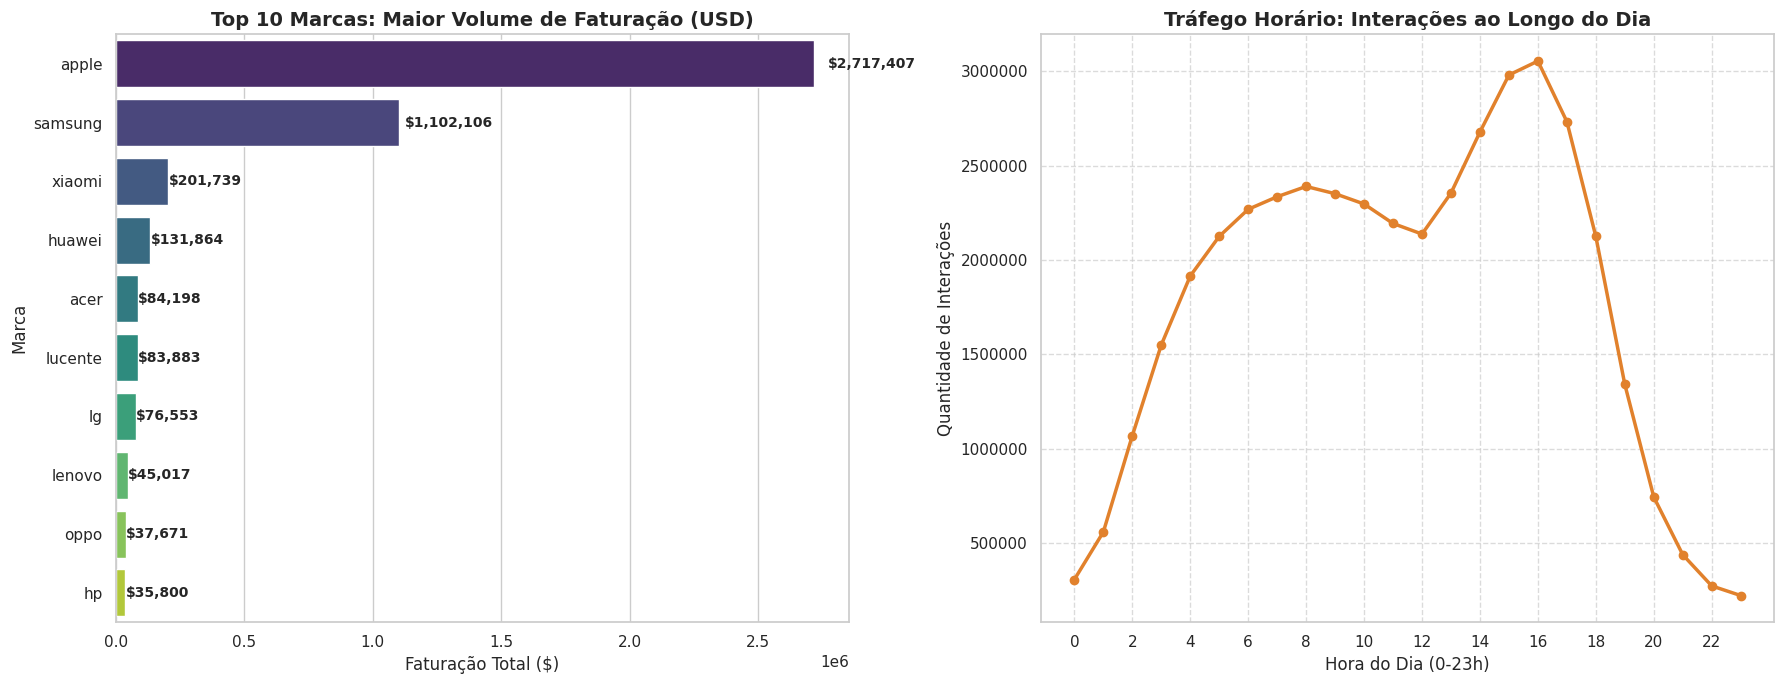

In [ ]:
# Configurar o estilo geral dos gráficos para manter a consistência visual
sns.set_theme(style="whitegrid")

# Criar uma figura com 2 subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: Top 10 Marcas com Maior Faturação

# Filtrar apenas as compras no chunk atual
purchases = df_chunk[df_chunk['event_type'] == 'purchase']

# Agrupar por marca, somar o preço e ordenar as 10 melhores
top_brands = purchases.groupby('brand', observed=True)['price'].sum().sort_values(ascending=False).head(10)

# Desenhar o gráfico de barras horizontal (o astype(str) corrige o bug das categorias vazias)
bars = sns.barplot(x=top_brands.values, y=top_brands.index.astype(str), ax=axes[0], palette="viridis")

# Formatação do gráfico de barras
axes[0].set_title('Top 10 Marcas: Maior Volume de Faturação (USD)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Faturação Total ($)', fontsize=12)
axes[0].set_ylabel('Marca', fontsize=12)

# Adicionar os valores exatos em dólares à frente de cada barra para melhor leitura técnica
for i, v in enumerate(top_brands.values):
    axes[0].text(v + (v * 0.02), i, f'${int(v):,}', va='center', fontsize=10, fontweight='bold')


# Gráfico 2: Tráfego Horário (Interações ao Longo do Dia)
axes[1].plot(events_by_hour.index, events_by_hour.values, marker='o', color='#E1812C', linewidth=2.5)

# Formatação do gráfico de linhas
axes[1].set_title('Tráfego Horário: Interações ao Longo do Dia', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hora do Dia (0-23h)', fontsize=12)
axes[1].set_ylabel('Quantidade de Interações', fontsize=12)
axes[1].set_xticks(range(0, 24, 2)) 

# Remove a notação científica para apresentar os números por extenso
axes[1].ticklabel_format(style='plain', axis='y') 
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Análise Crítica das Visualizações (Insights de Negócio)

**Interpretação Estratégica dos Resultados:**
1. **Domínio Financeiro do Mercado (Gráfico da Esquerda):**
   * O gráfico de barras horizontais revela uma concentração extrema de receita liderada pela **Apple** ($2,717,407), que fatura mais do que o dobro da sua concorrente direta, a **Samsung** ($1,102,106). 
   * Marcas historicamente fortes como a **Xiaomi** e a **Huawei** aparecem num segundo patamar de consumo, indicando que o público desta plataforma digital tem uma forte tendência para o consumo de produtos *premium*. 
   * **Insight:** Estratégias de marketing focadas em campanhas de retenção ou ecossistemas de acessórios para utilizadores Apple e Samsung trarão o maior retorno financeiro direto para a empresa.
2. **Padrão Logístico e Comportamental (Gráfico da Direita):**
   * A análise temporal das interações ao longo das 24 horas do dia mostra um crescimento acentuado a partir das 02:00h da manhã, estabilizando num primeiro patalho de tráfego entre as 06:00h e as 12:00h.
   * O **pico absoluto de tráfego** ocorre a meio da tarde, especificamente entre as **15:00h e as 16:00h** (ultrapassando as 3.000.000 de interações). Após as 18:00h, verifica-se uma quebra abrupta na atividade dos utilizadores.
   * **Insight Operacional:** Este comportamento indica que os utilizadores navegam intensamente durante o horário laboral/escolar. A equipa de engenharia de dados e infraestrutura deve utilizar estes dados para aplicar políticas de *Auto-Scaling* nos servidores, garantindo largura de banda máxima entre as 14:00h e as 17:00h e reduzindo custos computacionais no período noturno.